In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf

# Interaction Model

In [2]:
df = pd.read_csv("processed_f1_dataset.csv")

# Filter for the modern pit stop era and handle real-world outliers
# We exclude pre-2011 data (where pit times are 0) and filter out extreme outliers 
# (e.g., total pit times over 200 seconds, which usually indicate crash repairs or red flags).
df = df[(df['year'] >= 2011) & 
              (df['total_pit_time_sec'] > 0) & 
              (df['total_pit_time_sec'] < 200)].copy()

# Filter out DNFs for stronger correlation
df = df[df['statusId'] == 1]

# To model the interaction between overtaking difficulty and pit stop importance
# We need to develop a map for overtaking difficulty for each circuit/race
# We develop this by defining: position_change = abs(grid−positionOrder), avg position changes
df['position_change'] = abs(df['grid'] - df['positionOrder'])
#Define the difficulty for overtaking for each circuity by this avg
circuit_overtaking = (df.groupby('circuitRef')['position_change']
    .mean()
    .reset_index())

# Normalize and reverse order so we get: HIGH values = harder overtaking
scaler = MinMaxScaler()
circuit_overtaking['overtake_ease'] = scaler.fit_transform(
    circuit_overtaking[['position_change']])

circuit_overtaking['overtake_diff'] = (1 - circuit_overtaking['overtake_ease'])

# Merge back
df = df.merge(
    circuit_overtaking[['circuitRef', 'overtake_diff']],
    on='circuitRef',
    how='left')

# Interaction Model Definition
model = smf.ols(
    formula='positionOrder ~ total_pit_time_sec * overtake_diff',
    data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     24.11
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.11e-15
Time:                        21:25:11   Log-Likelihood:                -7812.8
No. Observations:                2779   AIC:                         1.563e+04
Df Residuals:                    2775   BIC:                         1.566e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

<Figure size 1000x600 with 0 Axes>

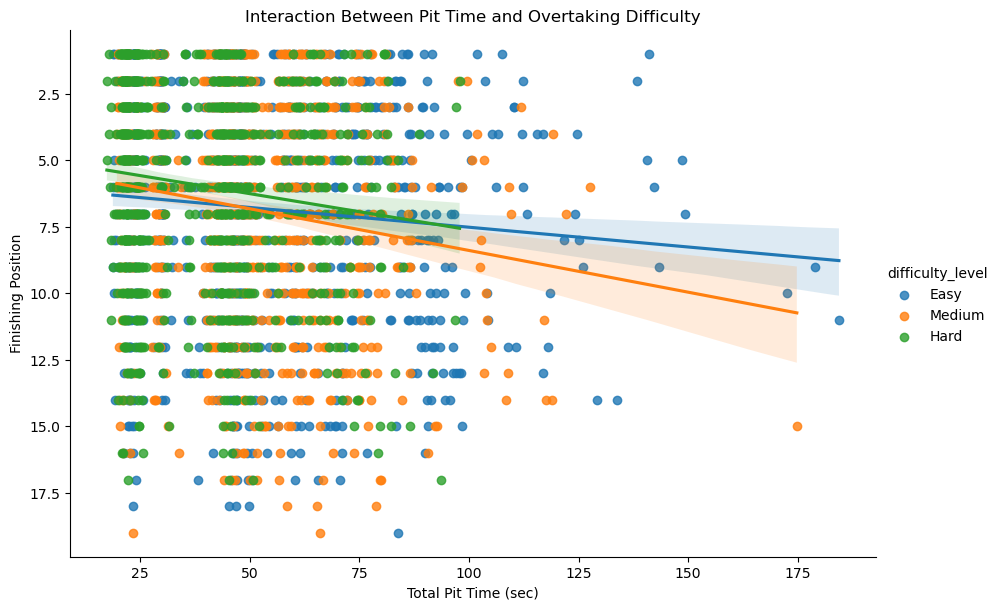

In [3]:
# Categorize circuit overtaking difficulty for easier visualization
df['difficulty_level'] = pd.qcut(
    df['overtake_diff'],
    q=3,
    labels=['Easy', 'Medium', 'Hard']
)

plt.figure(figsize=(10,6))

sns.lmplot(
    data=df,
    x='total_pit_time_sec',
    y='positionOrder',
    hue='difficulty_level',
    aspect=1.5,
    height=6
)

plt.title('Interaction Between Pit Time and Overtaking Difficulty')
plt.xlabel('Total Pit Time (sec)')
plt.ylabel('Finishing Position')
plt.gca().invert_yaxis()  #better finishes higher visually
plt.show()

These results suggest that pit stop time significantly depends on overtaking difficulty. We can conclude that longer pit times result in worse finishing positions, this correlation supports our first hypothesis. However, we should still control for potentially confounding variables like different racers, manufacturers, and starting positions:

# Interaction Model Controls

In [4]:
# Formula for controls C creates numeric vals for categorical variables
# Note that for almost all observations, driverIDs and contstructorIDs are highly correlated
# which should be obvious considering drivers drive usually for a single brand, so we only include driverID

# We should also mean center our interaction model to reduce insignificant correlations not important
# to our confounds: 
df['pit_centered'] = (
    df['total_pit_time_sec']
    - df['total_pit_time_sec'].mean())

df['diff_centered'] = (
    df['overtake_diff']
    - df['overtake_diff'].mean())

model = smf.ols(
    formula='positionOrder ~ pit_centered * diff_centered + grid + C(driverId)',
    data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     60.06
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        21:25:14   Log-Likelihood:                -6546.4
No. Observations:                2779   AIC:                         1.323e+04
Df Residuals:                    2708   BIC:                         1.366e+04
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

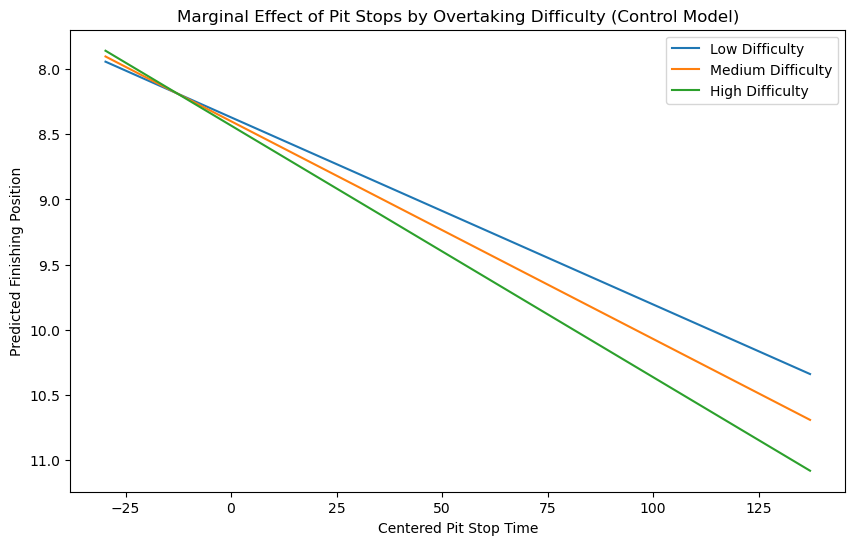

In [7]:
# For visualizations we are going to split model predictions based on overtaking difficulty
# We need to see how the model performs predictively

# Define difficulty by percentile to avg across drivers and grid
diff_low = df['diff_centered'].quantile(0.25)
diff_mid = df['diff_centered'].quantile(0.50)
diff_high = df['diff_centered'].quantile(0.75)

mean_grid = df['grid'].mean()

# all drivers
drivers = df['driverId'].unique()

def marginal_curve(pit_vals, diff_value):
    preds = []
    for d in drivers:
        temp = pd.DataFrame({
            'pit_centered': pit_vals,
            'diff_centered': diff_value,
            'grid': mean_grid,
            'driverId': d})

        preds.append(model.predict(temp))
    avg = np.mean(preds, axis=0)

    return pd.DataFrame({
        'pit_centered': pit_vals,
        'pred': avg
    })
low_curve = marginal_curve(pit_range, diff_low)
mid_curve = marginal_curve(pit_range, diff_mid)
high_curve = marginal_curve(pit_range, diff_high)

plt.figure(figsize=(10,6))

plt.plot(low_curve['pit_centered'], low_curve['pred'], label='Low Difficulty')
plt.plot(mid_curve['pit_centered'], mid_curve['pred'], label='Medium Difficulty')
plt.plot(high_curve['pit_centered'], high_curve['pred'], label='High Difficulty')

plt.xlabel('Centered Pit Stop Time')
plt.ylabel('Predicted Finishing Position')
plt.title('Marginal Effect of Pit Stops by Overtaking Difficulty (Control Model)')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

The controlled interaction model shows that the marginal effect of pit stop time on finishing position increases with overtaking difficulty, indicating that time lost in the pit lane is more costly on circuits where position recovery is harder. While the interaction effect is statistically significant, its magnitude is modest relative to stronger predictors such as starting grid position and driver-specific effects. This is reflected in the fact that most of the explained variance in finishing position is driven by these structural factors rather than pit stop performance alone (small R^2). 